<a href="https://colab.research.google.com/github/hrley55/BIG-DATA-NHOM-7/blob/main/Clustering%26Scikit_learnPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


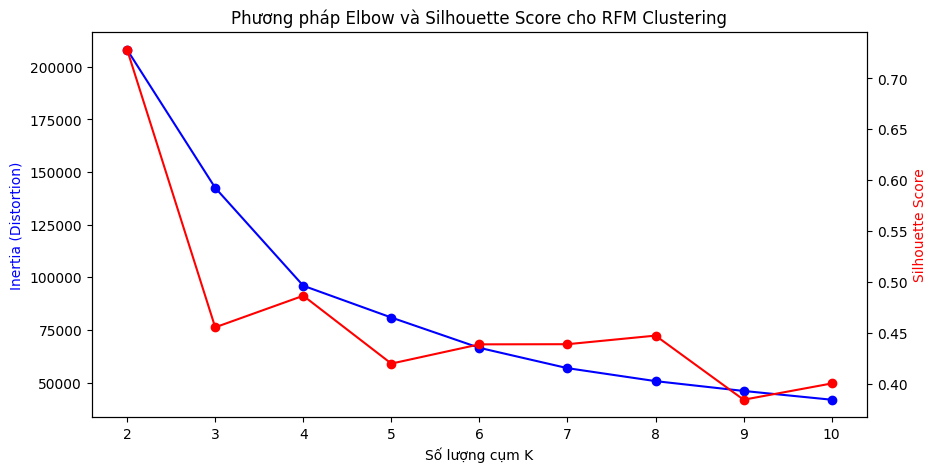

In [14]:
import joblib
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline


# --- BƯỚC 1: TẢI DỮ LIỆU VÀ TÍNH RFM ---
path_dir = kagglehub.dataset_download("olistbr/brazilian-ecommerce")


orders = pd.read_csv(os.path.join(path_dir, "olist_orders_dataset.csv"))
payments = pd.read_csv(os.path.join(path_dir, "olist_order_payments_dataset.csv"))
customers = pd.read_csv(os.path.join(path_dir, "olist_customers_dataset.csv"))


orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
df_master = orders.merge(customers, on='customer_id').merge(payments, on='order_id')


# RFM
snapshot_date = df_master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
rfm = df_master.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).rename(columns={'order_purchase_timestamp': 'Recency', 'order_id': 'Frequency', 'payment_value': 'Monetary'})


# --- BƯỚC 2: TIỀN XỬ LÝ (StandardScaler) ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


# --- BƯỚC 3: KHẢO SÁT RANGE K (2-10) ---
inertia = []
silhouette_avg = []
K_range = range(2, 11) # Chạy từ 2 đến 10


for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    # Silhouette score (lấy mẫu 20,000 dòng để tối ưu tốc độ tính toán)
    silhouette_avg.append(silhouette_score(rfm_scaled, labels, sample_size=20000))


# Vẽ biểu đồ Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Số lượng cụm K')
ax1.set_ylabel('Inertia (Distortion)', color='b')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_avg, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('Phương pháp Elbow và Silhouette Score cho RFM Clustering')
plt.show()

In [15]:
# --- BƯỚC 4.1: THỰC THI MODEL VỚI K TỐI ƯU (DÙNG PIPELINE) ---
k_opt = 4 # Con số này có được từ việc nhìn biểu đồ ở Bước 3

# 1. Định nghĩa KMeans Pipeline (Gom Scaler và Model vào 1 thực thể)
kmeans_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=k_opt, init='k-means++', n_init=10, max_iter=300, random_state=42))
])

# 2. Thực thi: Pipeline tự xử lý dữ liệu RFM chưa chuẩn hóa
# Kết quả labels trả về sẽ khớp 100% với cách chạy thủ công cũ
rfm['KMeans_Cluster'] = kmeans_pipeline.fit_predict(rfm[['Recency', 'Frequency', 'Monetary']])

# 3. Lưu Pipeline để dùng cho Streamlit (Cực kỳ quan trọng)
# File này chứa cả cách Scale dữ liệu và Model đã học
joblib.dump(kmeans_pipeline, 'kmeans_pipeline.joblib')

# --- BƯỚC 4.2: Tương tự cho GMM (Nếu muốn đóng gói Pipeline) ---
gmm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gmm', GaussianMixture(n_components=k_opt, covariance_type='full', random_state=42))
])
rfm['GMM_Cluster'] = gmm_pipeline.fit_predict(rfm[['Recency', 'Frequency', 'Monetary']])

# --- BƯỚC 5: XUẤT KẾT QUẢ VÀ SO SÁNH ---

print("\n" + "="*60)
print("PHÂN TÍCH KẾT QUẢ PHÂN CỤM (CLUSTERING ANALYSIS)")
print("="*60)

# In đặc trưng trung bình cho KMeans
print("\n[1] ĐẶC TRƯNG TRUNG BÌNH - MÔ HÌNH KMEANS:")
km_stats = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(km_stats)

# In đặc trưng trung bình cho GMM (Đáp ứng yêu cầu so sánh)
print("\n[2] ĐẶC TRƯNG TRUNG BÌNH - MÔ HÌNH GAUSSIAN MIXTURE (GMM):")
gmm_stats = rfm.groupby('GMM_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print(gmm_stats)

# So sánh số lượng khách hàng trong mỗi cụm
print("\n[3] SO SÁNH QUY MÔ PHÂN PHỐI CỤM:")
dist_comp = pd.DataFrame({
    'KMeans_Count': rfm['KMeans_Cluster'].value_counts(),
    'GMM_Count': rfm['GMM_Cluster'].value_counts()
}).sort_index()
print(dist_comp)

# --- BƯỚC 6: Ý NGHĨA KINH DOANH (Ví dụ dựa trên KMeans) ---
print("\n[4] DIỄN GIẢI Ý NGHĨA KINH DOANH (Dựa trên KMeans):")
for i in range(k_opt):
    row = km_stats.loc[i]
    if row['Monetary'] > km_stats['Monetary'].mean() and row['Frequency'] > 1.2:
        meaning = "Khách hàng VIP / Trung thành (Chi tiêu lớn, mua nhiều lần)"
    elif row['Recency'] < km_stats['Recency'].median():
        meaning = "Khách hàng Mới / Tiềm năng (Mới mua gần đây)"
    elif row['Recency'] > km_stats['Recency'].median():
        meaning = "Khách hàng Nguy cơ rời bỏ (Đã lâu không quay lại)"
    else:
        meaning = "Khách hàng Phổ thông"
    print(f" - Cluster {i}: {meaning}")

# --- BƯỚC 7: XUẤT FILE CHO STREAMLIT ---
rfm.to_csv("rfm_clustered.csv", index=True)
print("\n>>> Đã xuất file 'rfm_clustered.csv' thành công!")

# --- BƯỚC 8: TRỰC QUAN HÓA 3D ---
# Trực quan hóa KMeans
fig_km = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                        color='KMeans_Cluster', title='KMeans Clustering Visualization')
fig_km.show()

# Trực quan hóa GMM
fig_gmm = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                         color='GMM_Cluster', title='Gaussian Mixture Clustering Visualization')
fig_gmm.show()


PHÂN TÍCH KẾT QUẢ PHÂN CỤM (CLUSTERING ANALYSIS)

[1] ĐẶC TRƯNG TRUNG BÌNH - MÔ HÌNH KMEANS:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                438.80       1.00    134.93
1                289.49       1.02   1196.23
2                269.31       2.12    290.31
3                178.36       1.00    135.16

[2] ĐẶC TRƯNG TRUNG BÌNH - MÔ HÌNH GAUSSIAN MIXTURE (GMM):
             Recency  Frequency  Monetary
GMM_Cluster                              
0             170.64       1.00    215.42
1             309.46       1.00     86.79
2             270.83       2.09    394.37
3             355.83       1.00    574.12

[3] SO SÁNH QUY MÔ PHÂN PHỐI CỤM:
   KMeans_Count  GMM_Count
0         38655      16637
1          2422      66980
2          2962       3070
3         52056       9408

[4] DIỄN GIẢI Ý NGHĨA KINH DOANH (Dựa trên KMeans):
 - Cluster 0: Khách hàng Nguy cơ rời bỏ (Đã lâu không quay lại)
 - Cluster 1: Khách hàng Nguy cơ rời 

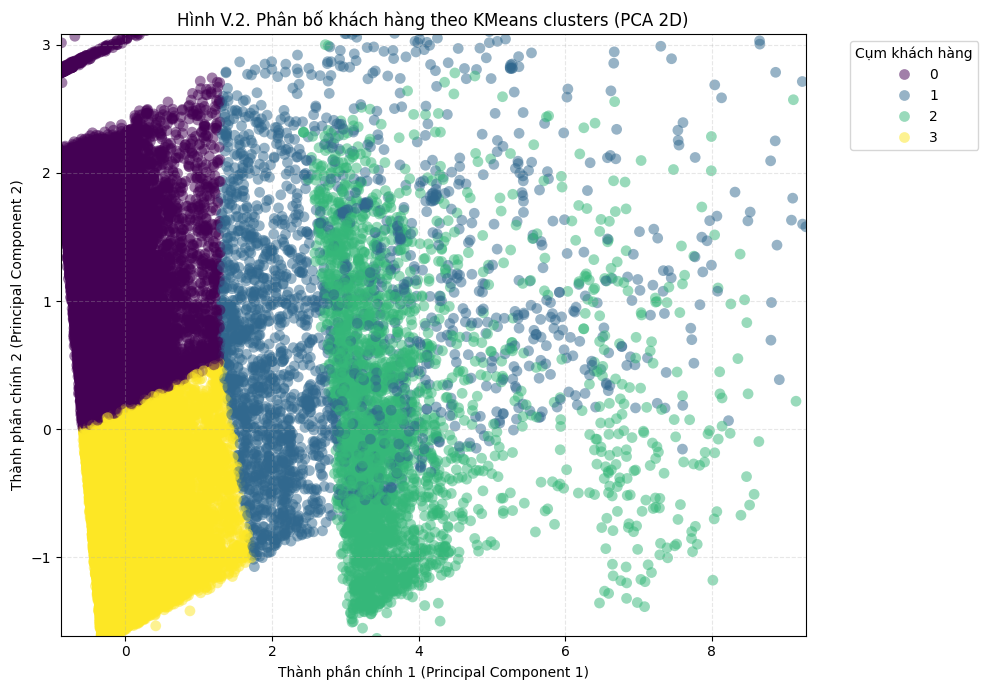

In [9]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Khởi tạo PCA để nén 3 chiều (R, F, M) xuống 2 chiều
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

# 2. Tạo DataFrame mới để vẽ, đảm bảo dùng đúng index của bảng rfm gốc
df_pca = pd.DataFrame(rfm_pca, columns=['PCA1', 'PCA2'], index=rfm.index)
df_pca['Cluster'] = rfm['KMeans_Cluster'] # Hoặc đổi thành 'GMM_Cluster' để so sánh

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    alpha=0.5,
    s=60,
    edgecolor='none'
)

# 4. Giới hạn trục tọa độ để tránh các điểm Outliers làm hình bị nhỏ (tránh lỗi trắng hình)
plt.xlim(df_pca['PCA1'].quantile(0.001), df_pca['PCA1'].quantile(0.999))
plt.ylim(df_pca['PCA2'].quantile(0.001), df_pca['PCA2'].quantile(0.999))

plt.title('Hình V.2. Phân bố khách hàng theo KMeans clusters (PCA 2D)')
plt.xlabel('Thành phần chính 1 (Principal Component 1)')
plt.ylabel('Thành phần chính 2 (Principal Component 2)')
plt.legend(title='Cụm khách hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

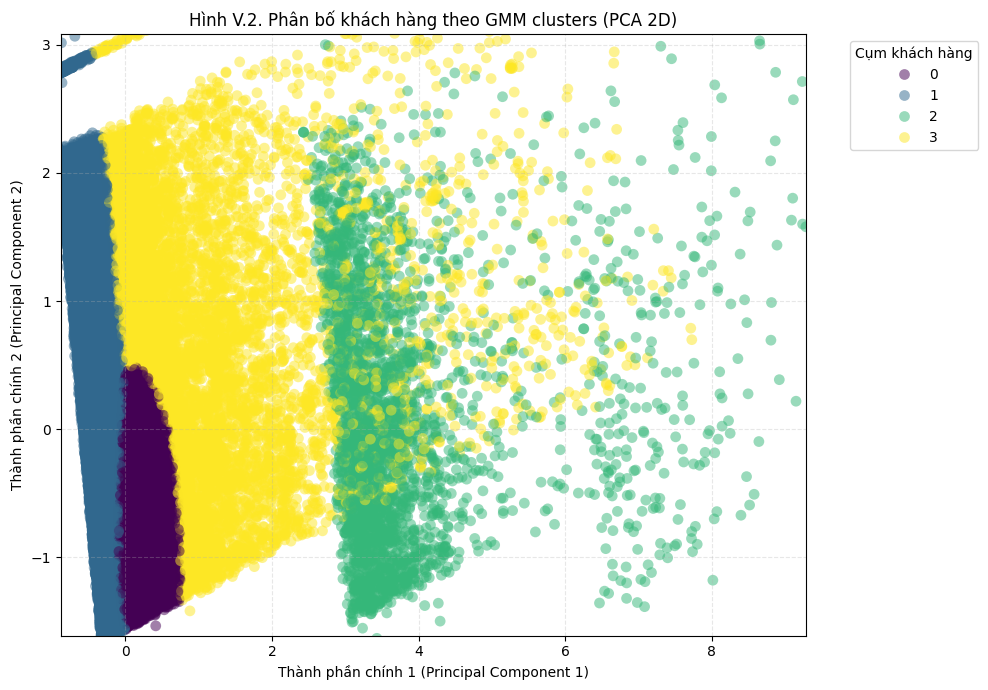

In [11]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Khởi tạo PCA để nén 3 chiều (R, F, M) xuống 2 chiều
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

# 2. Tạo DataFrame mới để vẽ, đảm bảo dùng đúng index của bảng rfm gốc
df_pca = pd.DataFrame(rfm_pca, columns=['PCA1', 'PCA2'], index=rfm.index)
df_pca['Cluster'] = rfm['GMM_Cluster'] # Hoặc đổi thành 'GMM_Cluster' để so sánh

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    data=df_pca,
    palette='viridis',
    alpha=0.5,
    s=60,
    edgecolor='none'
)

# 4. Giới hạn trục tọa độ để tránh các điểm Outliers làm hình bị nhỏ (tránh lỗi trắng hình)
plt.xlim(df_pca['PCA1'].quantile(0.001), df_pca['PCA1'].quantile(0.999))
plt.ylim(df_pca['PCA2'].quantile(0.001), df_pca['PCA2'].quantile(0.999))

plt.title('Hình V.2. Phân bố khách hàng theo GMM clusters (PCA 2D)')
plt.xlabel('Thành phần chính 1 (Principal Component 1)')
plt.ylabel('Thành phần chính 2 (Principal Component 2)')
plt.legend(title='Cụm khách hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, chi2

# 1. Định nghĩa các nhóm cột
num_cols = ['price', 'freight_value', 'product_weight_g']
cat_cols = ['customer_state', 'payment_type']

# 2. Xây dựng Transformer
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# 3. Full Pipeline kết hợp Feature Selection
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=chi2, k=50))
])